In [2]:
#import libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#load the dataset
!pip install kagglehub

import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df=pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe(include='all')#include all se ab object columns like name ka bhi aa rha hai descriptive statistics

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [7]:
df.shape

(48895, 16)

#EDA

1.missing values


2.univariate analysis(one variable at a time-distribuions,skewness)


3.bivariate analysis(relationship between features and the target)


4.correlation between numeric features


5.outlier inspection


In [8]:
#missing values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
#target variable 
df['room_type'].unique()


array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [10]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

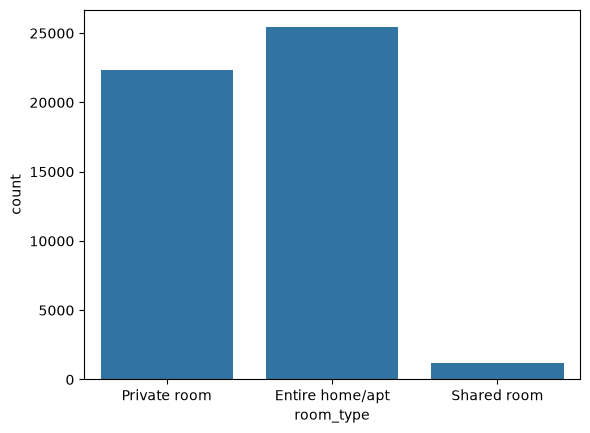

In [11]:
sns.countplot(x='room_type',data=df)

#the classes here all imbalanced--> shared room is small minority

#univariate Analysis-NUmeric features

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

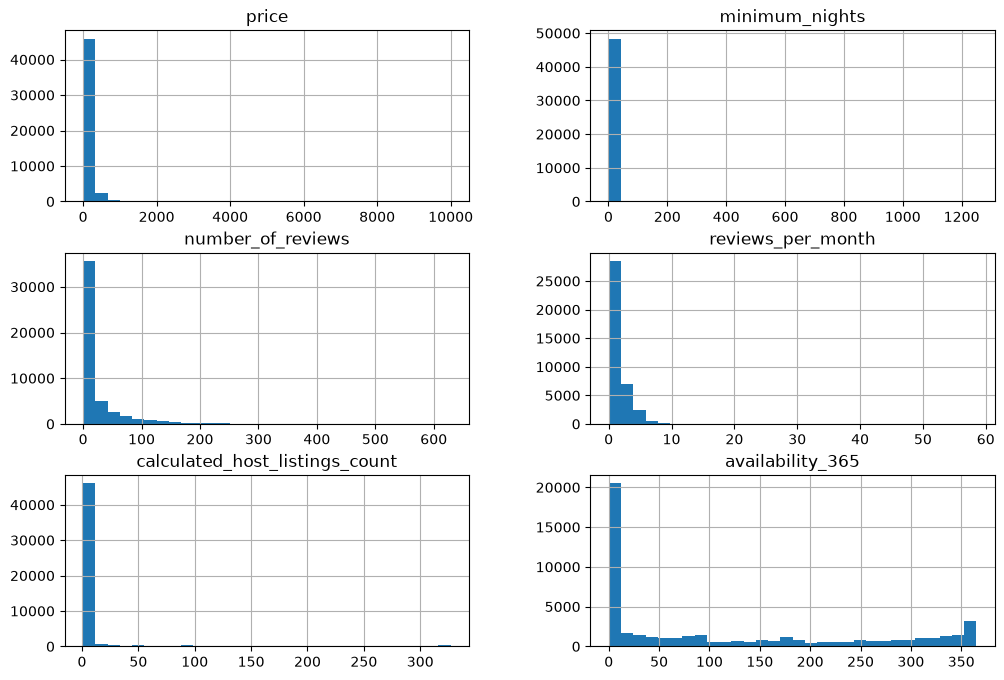

In [12]:
numerical_cols=[
    'price',
    'minimum_nights', 'number_of_reviews', 
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365']

df[numerical_cols].hist(bins=30,figsize=(12,8))


#univariate Analysis-categorical features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

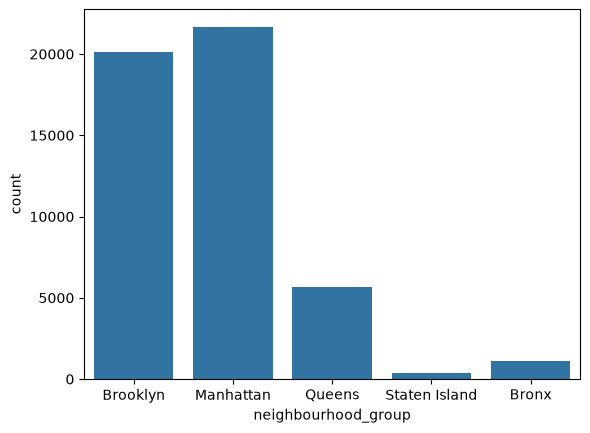

In [13]:
sns.countplot(data=df,x='neighbourhood_group')

#bivariate analysis-features vs target

<Axes: xlabel='room_type', ylabel='price'>

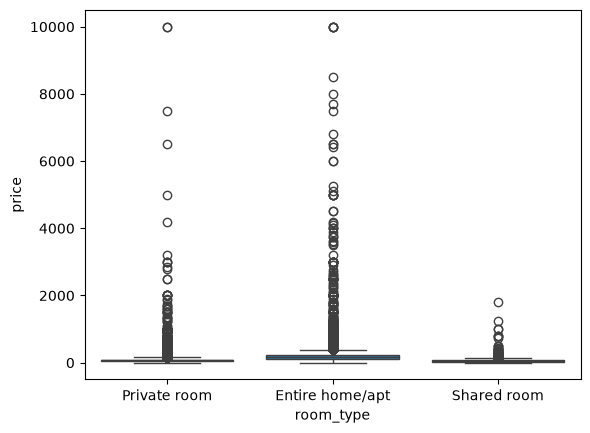

In [14]:
sns.boxplot(x='room_type',y='price',data=df)#you will notice too many outliers

#Correlation b/w numeric features

<Axes: >

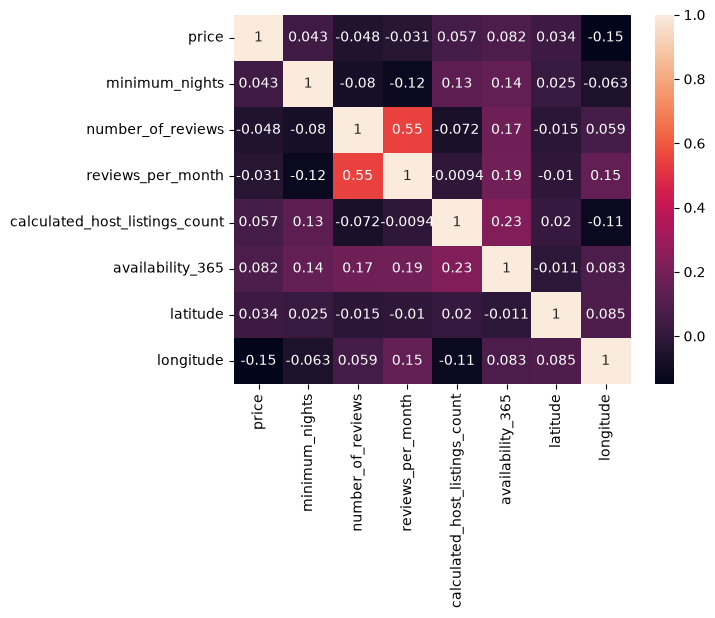

In [15]:
corr=df[numerical_cols+['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

#DATA CLEANING AND FEATURE ENGINEERING

1.DROP COLUMNS THAT ARE PURE IDENTIFIERS OR FREE TEXT AND CARRY NO GENERALIZABLE SIGNAL FOR A TABULAR MODEL(Id,name,host_id,host_name,last_review).

2.Fill missing reviews_per_month with 0 (no reviews yet).

3.Cap extreme outliers in price and minimum_nights using percentile clipping,so a handful of data-entry errors(e.g.$10,000/night,1,250 minimum nights) dont distort the model

4.Seperate features(X) from the target(y).

In [16]:
1.
df_clean=df.drop(columns=['id','name','host_id','host_name','last_review'])

#2. no reviews yet -->0 reviews per month thats not problem sirf uss mahine me 0 reviews aaye bas 0 yaha ek value hai null nahi
df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)

#3.just cap the extreme outliers instead of deleting them.

price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

#clip
df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df_clean['minimum_nights'].clip(upper=nights_cap)

#intead of clip we can also use 
#df_clean['price']=df_clean[df_clean['price'] < price_cap]
#df_clean['minimum_nights']=df_clean[df_clean['minimum_nights']<nights_cap]

    


In [17]:
X=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

#Train_test_split

WE HOLD OUT 20% OF THE DATA AS A TEST SET THAT IS NEVER TOUCHED DURING MODEL SELECTION OR TUNING-IT IS ONLY USED ONCE ,AT THE VERY END TO REPORT THE FINAL,HONEST PERFORMANCE. stratify=y keeps the same class proportions in both splits,which matters because the target is imbalanced


In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42,stratify=y)

6.Preprocessing:ColumnTransformer + Pipeline

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer # powertransformer is used to handle skewness
from sklearn.compose import ColumnTransformer

In [20]:
numerical_cols=['latitude', 'longitude',
       'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']


categorical_cols=['neighbourhood_group', 'neighbourhood']

#1.pipeline--> for numeric_columns

numeric_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy="median")),
    ('skewness',PowerTransformer(method="yeo-johnson")),
    ('scale',StandardScaler())
]
)


#2.pipeline-->for categorical_columns

categorical_pipeline=Pipeline(steps=[
   ('impute',SimpleImputer(strategy="most_frequent")),
   ('encode',OneHotEncoder(handle_unknown='ignore'))

])



preprocessor=ColumnTransformer(transformers=[
    ("numerical",numeric_pipeline,numerical_cols),
    ("categorical",categorical_pipeline,categorical_cols),
])


preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

SMOTE(synthetic minority oversampling) - class imbalance ke time use hota hai jaise yaha shared_room boht kam hai 
compared to baaki dono categories room_type apna target variable hai to yeh issue pe focus karna padega.
smote me ham shared_room ke synthetic values daalke uska count badhate hai but kynki ye values fake hi hoti hai for
now ham abhi isko use nhi karenge 


but disadvantages 

1.High chances of overfitting

2.data leakage


instaed of smote we will be using CLASS_WEIGHTS - isme ham just jo minority hai uspe jyada focus karenge 
                  

8.trying multiple algorithms

we will be using cross validation

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import  warnings 
warnings.filterwarnings('ignore')

In [22]:
#the problem here is GradientBoosting doesnt support class weight so we left GB as it is

models={
    "Logistic Regression": LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree":DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "Random Forest":RandomForestClassifier(class_weight='balanced',random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
    
}

for name,model in models.items():
    pipe=Pipeline(steps=[('preprocessor',preprocessor),("classifier",model)])


#accuracy alone can be misleading on imbalanced classes,so we use macro f1(f1_score)
#both:plain accuracy and macro F1 (which treats every class equally)
    
    accuracy=cross_val_score(pipe,X_train,y_train,cv=3,scoring='accuracy')
    macrof1=cross_val_score(pipe,X_train,y_train,cv=3,scoring='f1_macro')  

    print(f"{name}-> Accuracy:{accuracy.mean():.3f}, F1:{macrof1.mean():.3f}")


Logistic Regression-> Accuracy:0.727, F1:0.575
Decision Tree-> Accuracy:0.783, F1:0.651
Random Forest-> Accuracy:0.850, F1:0.731
Gradient Boosting-> Accuracy:0.848, F1:0.705


In [ ]:
# we will use randomforest
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(steps=[
    
    ('preprocessor',preprocessor),
    ("classifier",RandomForestClassifier(class_weight='balanced'))


]  )



    
param_distribution={
    "classifier__n_estimators":[100,200,150,300],
    "classifier__max_depth":[8,12,15,20,None],
    "classifier__min_samples_split":[2,5,10],
}
    

search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
)


search.fit(X_train,y_train)


In [ ]:
print("Best parameters:", search.best_params_)
print("Best CV Macro-F1:",search.best_score_)

10.Final Evaluation on the test set

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score

best_pipeline=search.best_estimator_
y_pred=best_pipeline.predict(X_test)

print("accuracy score:",accuracy_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred,average="macro"))

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt=".2f",xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

11.SAVING FINAL MODEL ARTIFACT

in production, the entire pipeline (precprocessing and model together) is serialized as a single artifact,so a new listing can be scored with one call no manual preprocessing required at inference time

In [ ]:
import joblib

joblib.dump(best_pipeline,"room_type_model.pkl")